In [1]:
from collections import defaultdict
from scipy import stats
from scipy.stats import erlang, expon, norm 
from itertools import product, combinations
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json

#### Extracting Global Time From Matrix?

# Tasks:

- [x] Make infect time histogram
- [x] Make path histogram
- [ ] Input data like Devlin's
    - [ ] format down, just need to support other distributions
- [ ] Distribution method like Devlin's 
    - [ ] may use Devlin's method of separate class resolver
    - [ ] Generalize Edge Distribtion assignment (custom CDFS)
        - [ ] can extend Devlin's edge resolver class to allow for custom cdfs via scipy.stats.rv
- [x] Test Random Graphs, with n nodes, 1 is src and n is end, check if graph is connected
    - [x] ER-model, parameterize n and p, 
    - [x] if connected run 1000+ simulations
        - [x] overall connected, we don't wnat to run simulations on small components
        - [x] graph is connect if laplacian rank is n-1, manually create 1x1 adjacency and degree matricies?, more efficient than bfs?
- [ ] may need to bench bfs compared to laplacian or just checking connectedness at graph initalization
    - Generally weary of having to create 2 new data structures just to calculate one thing

# Generality

How general is Graph Class implement:
- Multiple Src
- Single dst 
    - path construction does not check which dst to construct paths from
        - ie it expects a single dst as input
    - iteration stops once a single dst is infected
- $\exp(\lambda = 1)$ edge dst
- Lazy eval of edges
- Nodes have arbitrary labels

How general is EPR implement:
- Graph class can handle directedness or not
- Nodes can not have different dst or dst not exp(1)
- Our model can not have isolated nodes, only isolated connect components

In [ ]:
class Graph(object):

    def __init__(self, edge_json, node_size=None, directed=False):
        # graph data structures
        self._graph = defaultdict(set)
        # Node information
        self._infected = defaultdict(lambda : False) 
        self._simulated = defaultdict(lambda : False) 
        self._parent = defaultdict(lambda : None)
        self._node_infect_time = defaultdict(lambda : 0) 
        self.edge_set = self.make_edge_set(edge_json)
        # Graph creation
        self._directed = directed
        self.add_connections(self.edge_set)
        self._adjency_matrix = self.construct_matrix(self.edge_set)
        # Distribution information
        self._path_counts = defaultdict(lambda: 0)
        self._path_times = defaultdict(list)
        
    def add_connections(self, edge_set):
        for node1, node2, wt in edge_set:
            self.add_edge(node1,node2, wt)
            
    def add_edge(self, src, dst, wt):
        self._graph[src].add((dst, wt))
        if self._directed == False:
            self._graph[dst].add((src, wt))
            
    def construct_matrix(self, edge_set):
        df = pd.DataFrame(edge_set)
        df = df.pivot(index=0, columns=1, values=2)
        if self._directed == False:
            df = df.combine_first(df.T)
        if self._directed == True:
            idx = df.columns.union(df.index)
            df = df.reindex(index = idx, columns=idx, fill_value=np.inf)
        df = df.fillna(np.inf)
        return df

    # Make sure graph is using scipy.stats library
    def simulate_gossip_rv(self, src, dst, log=False):
        self.reset_simulation()
        
        if not self.is_connected:
            raise RuntimeError("Graph is not connected, generate a new graph")

        src = np.array([src]).flatten() # transform scalars and lists to iterables
        dst = np.array([dst]).flatten()
        global_t = 0
        
        for node in src:
            self._infected[node] = True
            self._node_infect_time[node] = 0
            
        if ((g._adjency_matrix.loc[src] == np.inf).all()).all():
            raise ValueError(f"Source node {src} is not in the graph")
        
        terminate = False
        while not terminate:
            current_tick_infected = [key for key in self._infected.keys() if self._infected[key] == True]

            if ((g._adjency_matrix.loc[np.array(current_tick_infected)] == np.inf).all()).all():
                raise ValueError("No path to dst")

            min_edge = None
            min_infect_time = np.inf
            for infected in current_tick_infected:
                # simulate new frontier infections
                for col, rv in enumerate(self._adjency_matrix.loc[infected]):
                    new_infection = self._adjency_matrix.columns[col]
                    path = self._adjency_matrix.loc[infected, new_infection]
                    # check if node has not been simulated/infected
                    if not self._simulated[(infected, new_infection)] and path != np.inf:
                        self._simulated[(infected, new_infection)] = True
                        edge_delay = rv.rvs() # scipy.stats dependency
                        self._adjency_matrix.loc[infected, new_infection] = edge_delay
                        if (self._directed == False):
                            self._adjency_matrix.loc[new_infection, infected] = edge_delay
                            self._simulated[(new_infection, infected)] = True
                        if log==True:
                            display(self._adjency_matrix)
                    if self._adjency_matrix.loc[infected, new_infection] < min_infect_time:
                        min_infect_time = self._adjency_matrix.loc[infected, new_infection] 
                        min_edge = (infected, new_infection)
            if self._parent[min_edge[1]] == None:
                self._parent[min_edge[1]] = min_edge[0]
                self._node_infect_time[min_edge[1]] = min_infect_time
                self._infected[min_edge[1]] = True
            self._adjency_matrix.loc[min_edge[0], min_edge[1]] = np.inf
            self._adjency_matrix.loc[current_tick_infected] = self._adjency_matrix.loc[current_tick_infected].sub(min_infect_time)
            if self._directed == False:
                self._adjency_matrix.loc[min_edge[1], min_edge[0]] = np.inf
                self._adjency_matrix.loc[:, current_tick_infected] = self._adjency_matrix.loc[:, current_tick_infected].sub(min_infect_time)
            if log==True:
                display(self._adjency_matrix)
            global_t = global_t + min_infect_time
            for node in dst:
                if self._infected[node]:
                    return global_t

    def reset_simulation(self):
        keys = self._graph.keys()
        for key in keys:
            self._infected[key] = False
            self._parent[key] = None
            self._node_infect_time[key] = 0
        for edge in product(keys, keys):
            self._simulated[edge] = False
        self._adjency_matrix = self.construct_matrix(self.edge_set)
    
    def reset_data(self):
        self._path_counts = defaultdict(lambda: 0)
        self._path_times = defaultdict(list)

    def construct_path(self, dst):
        path = []
        curr_node = dst
        while curr_node is not None:
            path.append(curr_node)
            curr_node = self._parent[curr_node]
        
        return path
    
    def make_edge_set(self, edge_json):
        edge_set = set()
        for key, value in edge_json.items():
            edges = key.split(',')
            distribution = self.process_distribution_params(value)
            edge_tuple = (edges[0], edges[1], distribution)
            edge_set.add(edge_tuple)
        return edge_set
                               
    def process_distribution_params(self, function_dict):
        distribution_map = {
            "E" : expon, # assuming params lambda = 1.0
            "N" : norm, # assuming unit normal
            "custom" : None, # customRV, # not working
        }
        distribution = distribution_map[function_dict["distribution"]]
        return distribution
    
    def simulation_trial(self, src, dst, iters=10**3):
        for i in range(iters):
            t = self.simulate_gossip_rv(src, dst)
            path = tuple(self.construct_path(dst))
            self._path_counts[path] = self._path_counts[path] + 1
            self._path_times[path].append(t)
            self.reset_simulation()
            
    def produce_histograms(self):
        compound_data = [times for times in self._path_times.values()]
        compound_time_data = np.concatenate(compound_data)
        path_count = len(self._path_times.keys())
        fig, axs = plt.subplots(2 + path_count, 1, figsize=(16, 4*(2 + path_count)))
        axs[0].hist(compound_data, bins="rice") #, 
        axs[0].set_title("Infection time distribution, all paths")
        path_names = [f"{path}" for path in self._path_counts.keys()]
        axs[1].barh(path_names, list(self._path_counts.values()))
        axs[1].set_title("Path distribution")
        for i, path in enumerate(self._path_times.keys()):
            axs[i + 2].hist(self._path_times[path], bins="rice")
            axs[i+2].set_title(f"Infection time distribution, condtioned on path {path}")
                               
    def is_connected(self):
        visited = set()
        node_list = set(self._graph.keys())
        current = node_list.pop()
        node_list.add(current)
        frontier = set(map(lambda x: x[0], self._graph[current]))
        while True:
            visited.add(current)
            frontier = set(map(lambda x: x[0], self._graph[current])) - visited
            if frontier: # empty check
                current = frontier.pop()
            else:
                return visited == node_list

In [180]:
# Assuming non-connectedness
def erdos_renyi(n, p, edge_dst=None, directed=False):
    verticies = list(range(n))
    edge = None
    if directed == False:
        edges = combinations(verticies, 2)
    else:
        edges = product(verticies, verticies)
    edge_set = {}
    for pair in edges:
        edge_paring = f"{pair[0]},{pair[1]}"
        if np.random.random() < p and pair[0] != pair[1]:
            edge_set[edge_paring] = {"distribution": "E", "parameters": {"lambda" : 1}}
    return Graph(new_set, directed=directed)

In [47]:
exp_t = lambda t: 1 - np.e**(-t)

edge_set = {
    "1,2": { "distribution": "E", "parameters": { "lambda" : 1.0 }}, 
    "1,3": { "distribution": "E", "parameters": { "lambda" : 1.0 }}, 
    "2,4": { "distribution": "E", "parameters": { "lambda" : 1.0 }}, 
    "2,5": { "distribution": "E", "parameters": { "lambda" : 1.0 }}, 
    "3,6": { "distribution": "E", "parameters": { "lambda" : 1.0 }}, 
    "4,5": { "distribution": "E", "parameters": { "lambda" : 1.0 }}, 
    "4,6": { "distribution": "E", "parameters": { "lambda" : 1.0 }}, 
}

g = Graph(edge_set)

In [48]:
((g._adjency_matrix.loc[np.array(['1','2'])] == np.inf).all()).all()

np.False_

#### Note: Columns don't actually do a good job of differentiating if a column is a string or int

In [49]:
g.reset_simulation()
g._adjency_matrix

,1,2,3,4,5,6
1,inf,<scipy.stats._continuous_distns.expon_gen obje...,<scipy.stats._continuous_distns.expon_gen obje...,inf,inf,inf
2,<scipy.stats._continuous_distns.expon_gen obje...,inf,inf,<scipy.stats._continuous_distns.expon_gen obje...,<scipy.stats._continuous_distns.expon_gen obje...,inf
3,<scipy.stats._continuous_distns.expon_gen obje...,inf,inf,inf,inf,<scipy.stats._continuous_distns.expon_gen obje...
4,inf,<scipy.stats._continuous_distns.expon_gen obje...,inf,inf,<scipy.stats._continuous_distns.expon_gen obje...,<scipy.stats._continuous_distns.expon_gen obje...
5,inf,<scipy.stats._continuous_distns.expon_gen obje...,inf,<scipy.stats._continuous_distns.expon_gen obje...,inf,inf
6,inf,inf,<scipy.stats._continuous_distns.expon_gen obje...,<scipy.stats._continuous_distns.expon_gen obje...,inf,inf


In [50]:
t = g.simulate_gossip_rv('1','6')
path = g.construct_path('6')
display(path)
print(f"Time: {t}")

['6', '3', '1']

Time: 0.7856517321162841


In [51]:
g._adjency_matrix

,1,2,3,4,5,6
1,inf,0.204718,inf,inf,inf,inf
2,0.204718,inf,inf,<scipy.stats._continuous_distns.expon_gen obje...,<scipy.stats._continuous_distns.expon_gen obje...,inf
3,inf,inf,inf,inf,inf,inf
4,inf,<scipy.stats._continuous_distns.expon_gen obje...,inf,inf,<scipy.stats._continuous_distns.expon_gen obje...,<scipy.stats._continuous_distns.expon_gen obje...
5,inf,<scipy.stats._continuous_distns.expon_gen obje...,inf,<scipy.stats._continuous_distns.expon_gen obje...,inf,inf
6,inf,inf,inf,<scipy.stats._continuous_distns.expon_gen obje...,inf,inf


In [52]:
g.reset_data()
g.reset_simulation()
g.simulation_trial('1', '6')

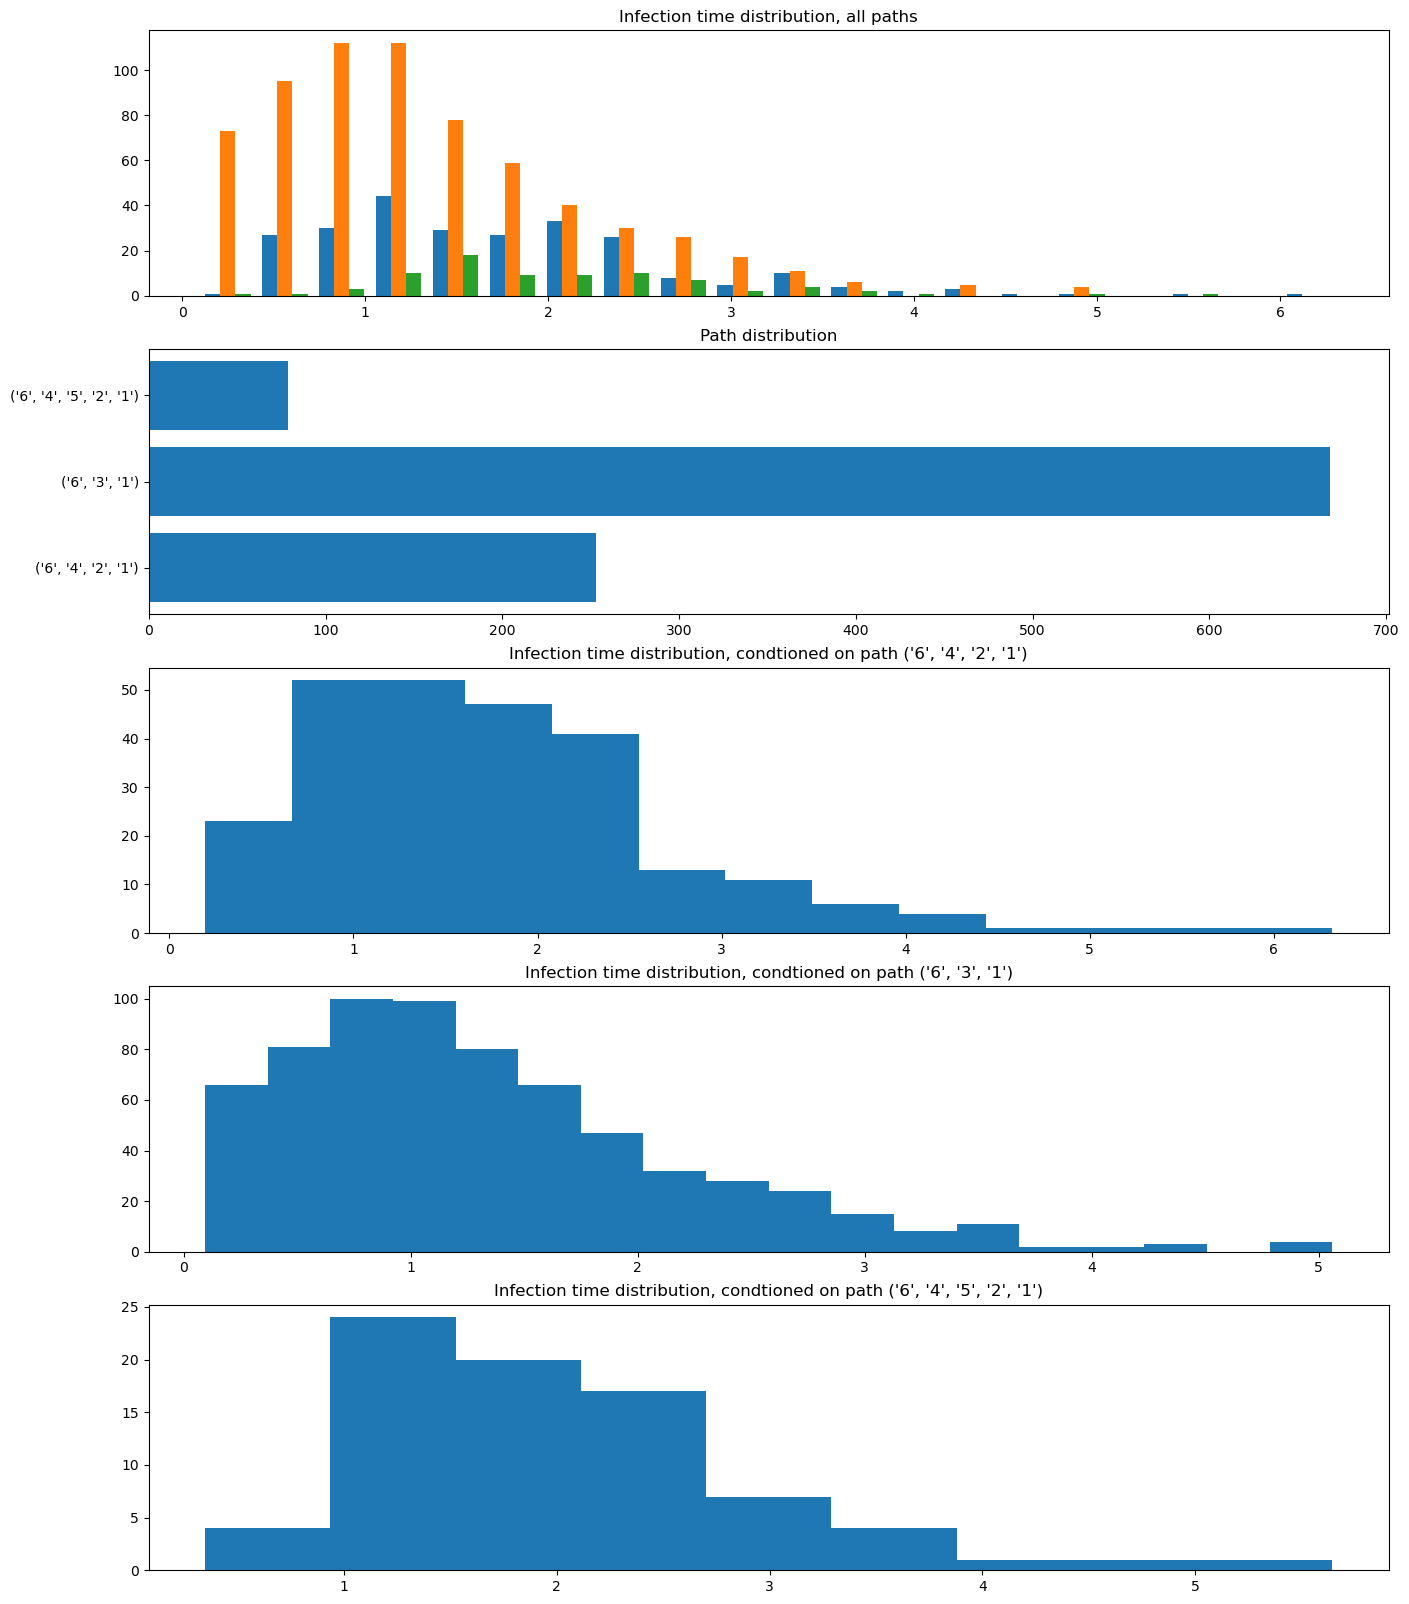

In [53]:
g.produce_histograms()
plt.show()

In [182]:
h = erdos_renyi(20, 0.1)
h.edge_set

{('0', '10', <scipy.stats._continuous_distns.expon_gen at 0x7f0e830ea660>),
 ('0', '12', <scipy.stats._continuous_distns.expon_gen at 0x7f0e830ea660>),
 ('0', '13', <scipy.stats._continuous_distns.expon_gen at 0x7f0e830ea660>),
 ('0', '19', <scipy.stats._continuous_distns.expon_gen at 0x7f0e830ea660>),
 ('0', '4', <scipy.stats._continuous_distns.expon_gen at 0x7f0e830ea660>),
 ('10', '17', <scipy.stats._continuous_distns.expon_gen at 0x7f0e830ea660>),
 ('10', '18', <scipy.stats._continuous_distns.expon_gen at 0x7f0e830ea660>),
 ('12', '19', <scipy.stats._continuous_distns.expon_gen at 0x7f0e830ea660>),
 ('2', '7', <scipy.stats._continuous_distns.expon_gen at 0x7f0e830ea660>),
 ('3', '5', <scipy.stats._continuous_distns.expon_gen at 0x7f0e830ea660>),
 ('4', '11', <scipy.stats._continuous_distns.expon_gen at 0x7f0e830ea660>),
 ('4', '17', <scipy.stats._continuous_distns.expon_gen at 0x7f0e830ea660>),
 ('4', '5', <scipy.stats._continuous_distns.expon_gen at 0x7f0e830ea660>),
 ('5', '16', 

In [184]:
h._adjency_matrix

,0,10,11,12,13,16,17,18,19,2,3,4,5,6,7,9
0,inf,<scipy.stats._continuous_distns.expon_gen obje...,inf,<scipy.stats._continuous_distns.expon_gen obje...,<scipy.stats._continuous_distns.expon_gen obje...,inf,inf,inf,<scipy.stats._continuous_distns.expon_gen obje...,inf,inf,<scipy.stats._continuous_distns.expon_gen obje...,inf,inf,inf,inf
10,<scipy.stats._continuous_distns.expon_gen obje...,inf,inf,inf,inf,inf,<scipy.stats._continuous_distns.expon_gen obje...,<scipy.stats._continuous_distns.expon_gen obje...,inf,inf,inf,inf,inf,inf,inf,inf
11,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,<scipy.stats._continuous_distns.expon_gen obje...,inf,inf,inf,inf
12,<scipy.stats._continuous_distns.expon_gen obje...,inf,inf,inf,inf,inf,inf,inf,<scipy.stats._continuous_distns.expon_gen obje...,inf,inf,inf,inf,inf,inf,inf
13,<scipy.stats._continuous_distns.expon_gen obje...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
16,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,<scipy.stats._continuous_distns.expon_gen obje...,inf,inf,inf
17,inf,<scipy.stats._continuous_distns.expon_gen obje...,inf,inf,inf,inf,inf,inf,inf,inf,inf,<scipy.stats._continuous_distns.expon_gen obje...,inf,inf,inf,inf
18,inf,<scipy.stats._continuous_distns.expon_gen obje...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
19,<scipy.stats._continuous_distns.expon_gen obje...,inf,inf,<scipy.stats._continuous_distns.expon_gen obje...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,<scipy.stats._continuous_distns.expon_gen obje...
2,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,<scipy.stats._continuous_distns.expon_gen obje...,inf


In [185]:
h.is_connected()

False

In [186]:
set(h._graph.keys())

{'0',
 '10',
 '11',
 '12',
 '13',
 '16',
 '17',
 '18',
 '19',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '9'}